# Análise de Desempenho por Tipo de Lesão

Avalia o desempenho dos melhores modelos das Trilhas A e B no conjunto de teste,
estratificando os resultados por tipo de lesão (`dx`) extraído do banco de dados original.

**Pipeline:**
1. Enriquece os CSVs de radiomics com a coluna `dx` (tipo de lesão)
2. Carrega modelos finais treinados nas Trilhas A e B
3. Gera predições no conjunto de teste
4. Calcula acurácia e n_correto por tipo de lesão
5. Visualiza resultados comparativos entre datasets e trilhas

## Env Configuration

Importações, caminhos, parâmetros globais e carregamento do mapeamento `image_id → dx` do banco de dados original.

In [ ]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR       = os.path.join(PROJECT_ROOT, 'data', 'images', 'datasets')
RAW_DIR        = os.path.join(PROJECT_ROOT, 'data', 'raw', 'us-derma-kaggle')
MODULES_DIR    = os.path.join(PROJECT_ROOT, 'modules')
INPUT_A_DIR    = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_a')
INPUT_B_DIR    = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_b')
OUTPUT_A_DIR   = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_a_final')
OUTPUT_B_DIR   = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_b_final')
OUTPUT_DIR     = os.path.join(PROJECT_ROOT, 'experiments', 'analise_por_tipo_lesao')

if MODULES_DIR not in sys.path:
    sys.path.insert(0, MODULES_DIR)

from models import ALL_CLASSIFIERS, build_selectkbest_pipeline, build_plain_pipeline
from evaluation import META_COLS, DATASETS, DS_COLORS, compute_metrics, youden_threshold
from lesion_metadata import parse_database_csv, add_dx_to_radiomics, accuracy_by_lesion

os.makedirs(OUTPUT_DIR, exist_ok=True)

K_FEATURES_A = 20
VAL_SIZE     = 0.20
SEED         = 42

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 9

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'DATA_DIR     : {DATA_DIR}')
print(f'OUTPUT_DIR   : {OUTPUT_DIR}')

## Functions

`parse_database_csv`, `add_dx_to_radiomics` e `accuracy_by_lesion` vêm de `modules/lesion_metadata.py`.
`youden_threshold` vem de `modules/evaluation.py`. `build_selectkbest_pipeline`/`build_plain_pipeline`
vêm de `modules/models.py` (o fit é feito explicitamente com `.fit(X_tv, y_tv)`).

## Process

Execução completa da análise por tipo de lesão para Trilha A e Trilha B.

### 1. Carregamento do mapeamento image_id → dx

In [4]:
raw_csv = os.path.join(RAW_DIR, '201database.csv')
df_dx   = parse_database_csv(raw_csv)

print(f'Mapeamento carregado: {len(df_dx)} imagens')
print(f'Tipos de lesão únicos: {df_dx["dx"].nunique()}')
display(df_dx.groupby('dx').size().reset_index(name='n').sort_values('n', ascending=False).head(20))

Mapeamento carregado: 202 imagens
Tipos de lesão únicos: 29


,dx,n
3,CYST,48
2,BCC,39
15,LIPOMA,30
4,DERMATOFIBROMA,22
22,SCC,14
0,AK,6
25,SEBORRHEIC KERATOSIS,5
18,METASTASIS,5
24,SEBK,4
1,ANGIOMA,3


### 2. Enriquecer CSVs de radiomics com coluna dx e salvar

In [5]:
for ds_name, ds_file in DATASETS.items():
    csv_path = os.path.join(DATA_DIR, ds_file)
    df_rad   = pd.read_csv(csv_path)

    if 'dx' in df_rad.columns:
        print(f'{ds_name}: coluna dx já existe — pulando.')
        continue

    df_rad_dx = add_dx_to_radiomics(df_rad, df_dx)
    n_missing = df_rad_dx['dx'].isna().sum()

    df_rad_dx.to_csv(csv_path, index=False)
    print(f'{ds_name}: dx adicionado → {csv_path}')
    print(f'  {len(df_rad_dx)} linhas | dx ausentes: {n_missing}')

print('\nCSVs atualizados.')

BW: dx adicionado → c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\data\processed\radiomics\radiomics_bw.csv
  198 linhas | dx ausentes: 0
Doppler: dx adicionado → c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\data\processed\radiomics\radiomics_doppler.csv
  198 linhas | dx ausentes: 0
BW+Doppler: dx adicionado → c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\data\processed\radiomics\radiomics_bw_doppler.csv
  198 linhas | dx ausentes: 0

CSVs atualizados.


### 3. Carregamento dos datasets e modelos selecionados

In [6]:
clf_map = dict(ALL_CLASSIFIERS)

META_COLS_EXT = META_COLS + ['dx']   # colunas a excluir das features

dfs = {}
for ds_name, ds_file in DATASETS.items():
    df = pd.read_csv(os.path.join(DATA_DIR, ds_file))
    dfs[ds_name] = df
    test = df[df['split'] == 'test']
    print(f'{ds_name}: {len(df)} total | {len(test)} teste | dx nulos={test["dx"].isna().sum()}')

df_top_a = pd.read_csv(os.path.join(INPUT_A_DIR, 'task5_top_models.csv'))
df_top_b = pd.read_csv(os.path.join(INPUT_B_DIR, 'task5_top_models.csv'))

print(f'\nModelos Trilha A: {len(df_top_a)}')
display(df_top_a[['dataset', 'model', 'auc_mean']])
print(f'\nModelos Trilha B: {len(df_top_b)}')
display(df_top_b[['dataset', 'model', 'auc_mean']])

BW: 198 total | 20 teste | dx nulos=0
Doppler: 198 total | 20 teste | dx nulos=0
BW+Doppler: 198 total | 20 teste | dx nulos=0

Modelos Trilha A: 3


,dataset,model,auc_mean
0,BW,Coarse Gaussian SVM,0.778986
1,Doppler,Subspace Discriminant,0.825428
2,BW+Doppler,Subspace Discriminant,0.807905



Modelos Trilha B: 3


,dataset,model,auc_mean
0,BW,Medium Gaussian SVM,0.798485
1,Doppler,Medium Gaussian SVM,0.825033
2,BW+Doppler,Medium Gaussian SVM,0.814822


### 4. Treino final e predições no teste — Trilha A

In [ ]:
splits_a      = {}
test_preds_a  = {}

for ds_name, df in dfs.items():
    feat_cols = [c for c in df.columns if c not in META_COLS_EXT]
    trainval  = df[df['split'] == 'trainval']
    test      = df[df['split'] == 'test']

    X_tv = trainval[feat_cols].values.astype(float)
    y_tv = trainval['target'].values
    X_te = test[feat_cols].values.astype(float)
    y_te = test['target'].values

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tv, y_tv, test_size=VAL_SIZE, stratify=y_tv, random_state=SEED
    )

    splits_a[ds_name] = {
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_te, 'y_test': y_te,
        'dx_test': test['dx'].reset_index(drop=True),
    }

    row_top    = df_top_a[df_top_a['dataset'] == ds_name].iloc[0]
    model_name = row_top['model']
    k_eff      = min(K_FEATURES_A, X_tv.shape[1])

    pipe = build_selectkbest_pipeline(clone(clf_map[model_name]), k_eff)
    pipe.fit(X_tv, y_tv)

    prob_val  = pipe.predict_proba(X_val)[:, 1]
    prob_test = pipe.predict_proba(X_te)[:, 1]
    thr       = youden_threshold(y_val, prob_val)

    y_pred_05     = (prob_test >= 0.5).astype(int)
    y_pred_youden = (prob_test >= thr).astype(int)

    test_preds_a[ds_name] = {
        'model': model_name,
        'prob':          prob_test,
        'pred_05':       y_pred_05,
        'pred_youden':   y_pred_youden,
        'thr_youden':    thr,
    }
    print(f'{ds_name} | {model_name} | thr_youden={thr:.3f}')

print('\nTrilha A — treinos concluídos.')

### 5. Treino final e predições no teste — Trilha B

In [ ]:
splits_b      = {}
test_preds_b  = {}

for ds_name, df in dfs.items():
    feat_cols = [c for c in df.columns if c not in META_COLS_EXT]
    trainval  = df[df['split'] == 'trainval']
    test      = df[df['split'] == 'test']

    X_tv = trainval[feat_cols].values.astype(float)
    y_tv = trainval['target'].values
    X_te = test[feat_cols].values.astype(float)
    y_te = test['target'].values

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tv, y_tv, test_size=VAL_SIZE, stratify=y_tv, random_state=SEED
    )

    splits_b[ds_name] = {
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_te, 'y_test': y_te,
        'dx_test': test['dx'].reset_index(drop=True),
    }

    row_top    = df_top_b[df_top_b['dataset'] == ds_name].iloc[0]
    model_name = row_top['model']

    pipe = build_plain_pipeline(clone(clf_map[model_name]))
    pipe.fit(X_tv, y_tv)

    prob_val  = pipe.predict_proba(X_val)[:, 1]
    prob_test = pipe.predict_proba(X_te)[:, 1]
    thr       = youden_threshold(y_val, prob_val)

    y_pred_05     = (prob_test >= 0.5).astype(int)
    y_pred_youden = (prob_test >= thr).astype(int)

    test_preds_b[ds_name] = {
        'model': model_name,
        'prob':          prob_test,
        'pred_05':       y_pred_05,
        'pred_youden':   y_pred_youden,
        'thr_youden':    thr,
    }
    print(f'{ds_name} | {model_name} | thr_youden={thr:.3f}')

print('\nTrilha B — treinos concluídos.')

### 6. Tabelas de acurácia por tipo de lesão

In [9]:
summary_rows = []

for trilha, test_preds, splits_dict in [
    ('A', test_preds_a, splits_a),
    ('B', test_preds_b, splits_b),
]:
    for ds_name in DATASETS:
        sp    = splits_dict[ds_name]
        preds = test_preds[ds_name]
        y_te  = sp['y_test']
        dx_te = sp['dx_test']

        for thr_label, y_pred in [('thr=0.5', preds['pred_05']),
                                   ('Youden',  preds['pred_youden'])]:
            df_by_lesion = accuracy_by_lesion(y_te, y_pred, dx_te)
            df_by_lesion['dataset']   = ds_name
            df_by_lesion['trilha']    = f'Trilha {trilha}'
            df_by_lesion['model']     = preds['model']
            df_by_lesion['threshold'] = thr_label
            summary_rows.append(df_by_lesion)

df_summary = pd.concat(summary_rows, ignore_index=True)

# Salvar CSV completo
out_csv = os.path.join(OUTPUT_DIR, 'accuracy_by_lesion_type.csv')
df_summary.to_csv(out_csv, index=False)
print(f'Salvo: {out_csv}  ({len(df_summary)} linhas)\n')

# Exibir tabela para threshold=0.5
print('=== Acurácia por tipo de lesão (threshold=0.5) ===')
display(
    df_summary[df_summary['threshold'] == 'thr=0.5']
    [['trilha', 'dataset', 'model', 'dx', 'label', 'n_images', 'n_correct', 'accuracy']]
    .sort_values(['trilha', 'dataset', 'label', 'accuracy'])
    .reset_index(drop=True)
    .style.format({'accuracy': '{:.2%}'})
    .background_gradient(subset=['accuracy'], cmap='RdYlGn')
)

Salvo: c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\analise_por_tipo_lesao\accuracy_by_lesion_type.csv  (96 linhas)

=== Acurácia por tipo de lesão (threshold=0.5) ===


,trilha,dataset,model,dx,label,n_images,n_correct,accuracy
0,Trilha A,BW,Coarse Gaussian SVM,CYST,BENIGN,6,6,100.00%
1,Trilha A,BW,Coarse Gaussian SVM,INTRADERMAL NEVUS,BENIGN,1,1,100.00%
2,Trilha A,BW,Coarse Gaussian SVM,LIPOMA,BENIGN,4,4,100.00%
3,Trilha A,BW,Coarse Gaussian SVM,SCHWANOMA,BENIGN,1,1,100.00%
4,Trilha A,BW,Coarse Gaussian SVM,SEBORRHEIC KERATOSIS,BENIGN,1,1,100.00%
5,Trilha A,BW,Coarse Gaussian SVM,AK,MALIGNANT,1,0,0.00%
6,Trilha A,BW,Coarse Gaussian SVM,BCC,MALIGNANT,3,2,66.67%
7,Trilha A,BW,Coarse Gaussian SVM,SCC,MALIGNANT,3,3,100.00%
8,Trilha A,BW+Doppler,Subspace Discriminant,CYST,BENIGN,6,6,100.00%
9,Trilha A,BW+Doppler,Subspace Discriminant,INTRADERMAL NEVUS,BENIGN,1,1,100.00%


### 7. Visualização — Acurácia por tipo de lesão (threshold=0.5)

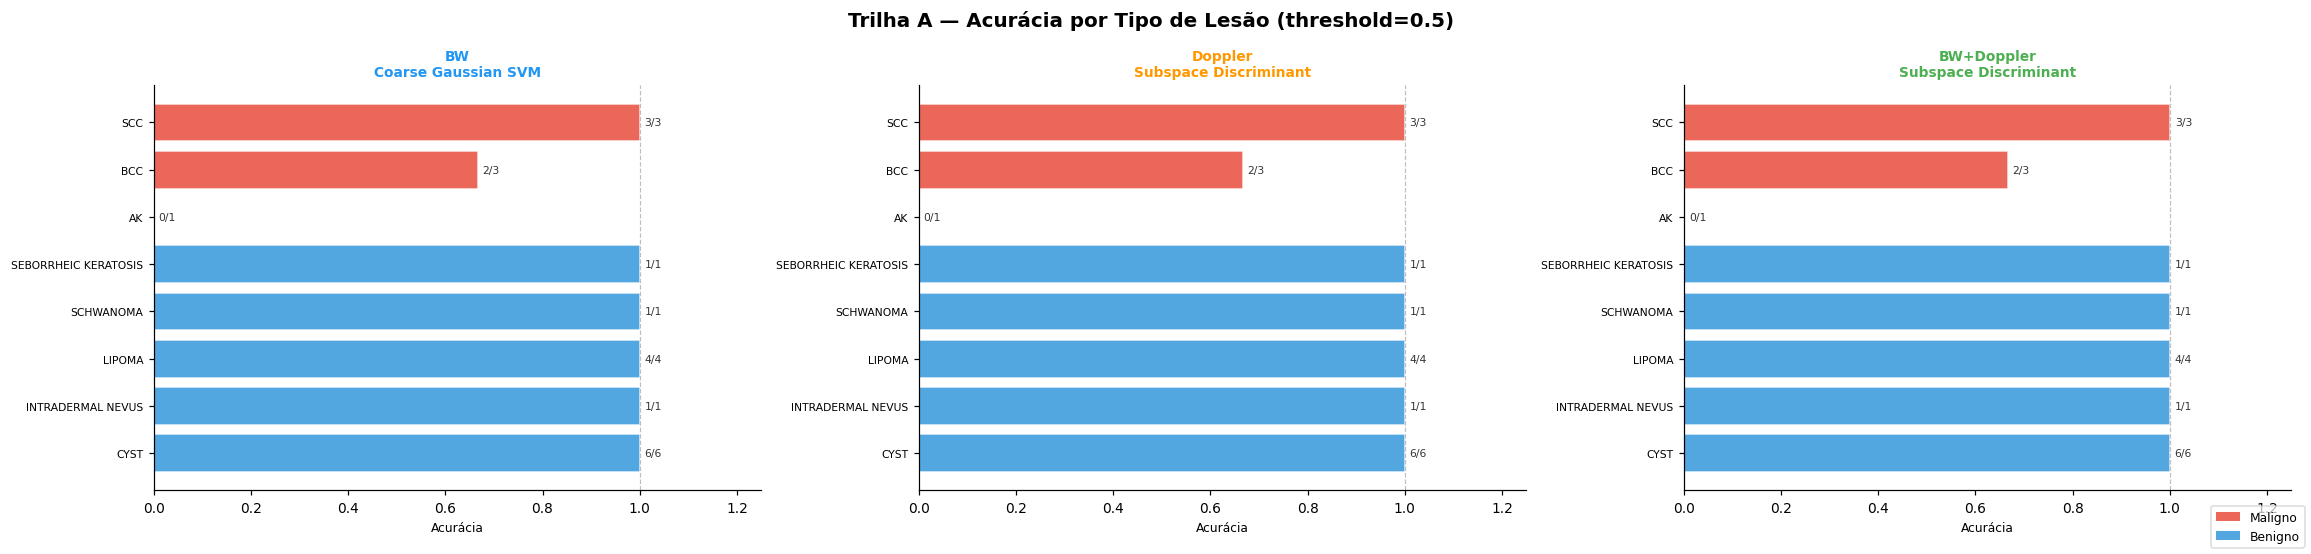

Salvo: c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\analise_por_tipo_lesao\trilha_a_accuracy_by_lesion.png


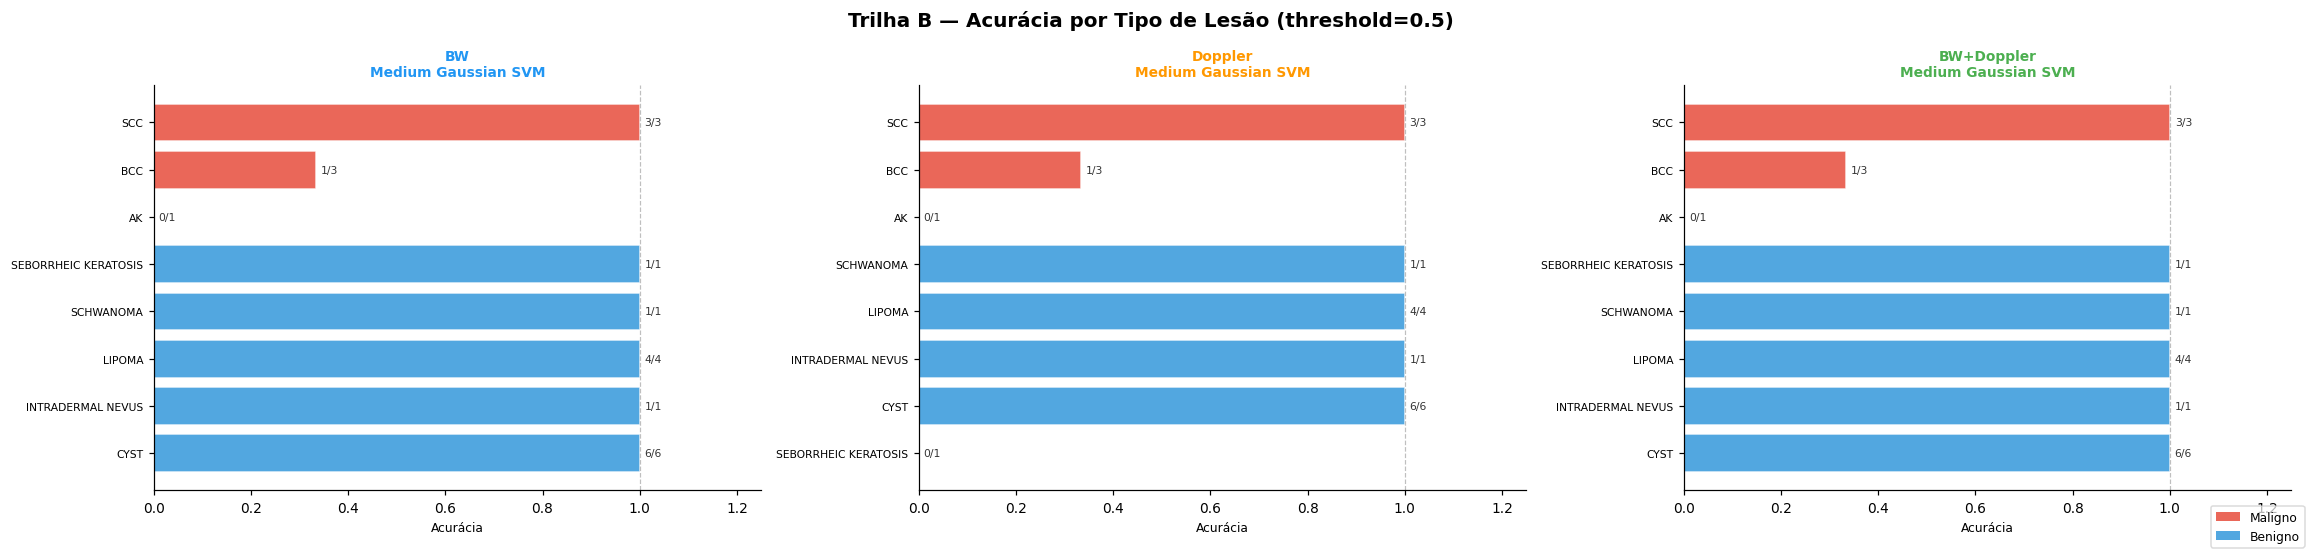

Salvo: c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\analise_por_tipo_lesao\trilha_b_accuracy_by_lesion.png


In [10]:
for trilha, test_preds, splits_dict in [
    ('A', test_preds_a, splits_a),
    ('B', test_preds_b, splits_b),
]:
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    fig.suptitle(f'Trilha {trilha} — Acurácia por Tipo de Lesão (threshold=0.5)',
                 fontsize=13, fontweight='bold')

    for ax, ds_name in zip(axes, DATASETS.keys()):
        sp    = splits_dict[ds_name]
        preds = test_preds[ds_name]
        y_te  = sp['y_test']
        dx_te = sp['dx_test']

        df_bl = accuracy_by_lesion(y_te, preds['pred_05'], dx_te)
        colors = ['#e74c3c' if l == 'MALIGNANT' else '#3498db' for l in df_bl['label']]

        bars = ax.barh(df_bl['dx'], df_bl['accuracy'], color=colors, alpha=0.85,
                       edgecolor='white')

        # Anotar n/total
        for bar, (_, row) in zip(bars, df_bl.iterrows()):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{int(row["n_correct"])}/{int(row["n_images"])}',
                    va='center', ha='left', fontsize=7, color='#333')

        ax.set_xlim(0, 1.25)
        ax.axvline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.set_xlabel('Acurácia', fontsize=8)
        ax.set_title(f'{ds_name}\n{preds["model"]}', fontsize=9,
                     fontweight='bold', color=DS_COLORS[ds_name])
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='y', labelsize=7)

    # Legenda manual de cores
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', alpha=0.85, label='Maligno'),
        Patch(facecolor='#3498db', alpha=0.85, label='Benigno'),
    ]
    fig.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.7)

    plt.tight_layout()
    out_png = os.path.join(OUTPUT_DIR, f'trilha_{trilha.lower()}_accuracy_by_lesion.png')
    plt.savefig(out_png, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Salvo: {out_png}')

### 8. Comparação Trilha A vs Trilha B por tipo de lesão

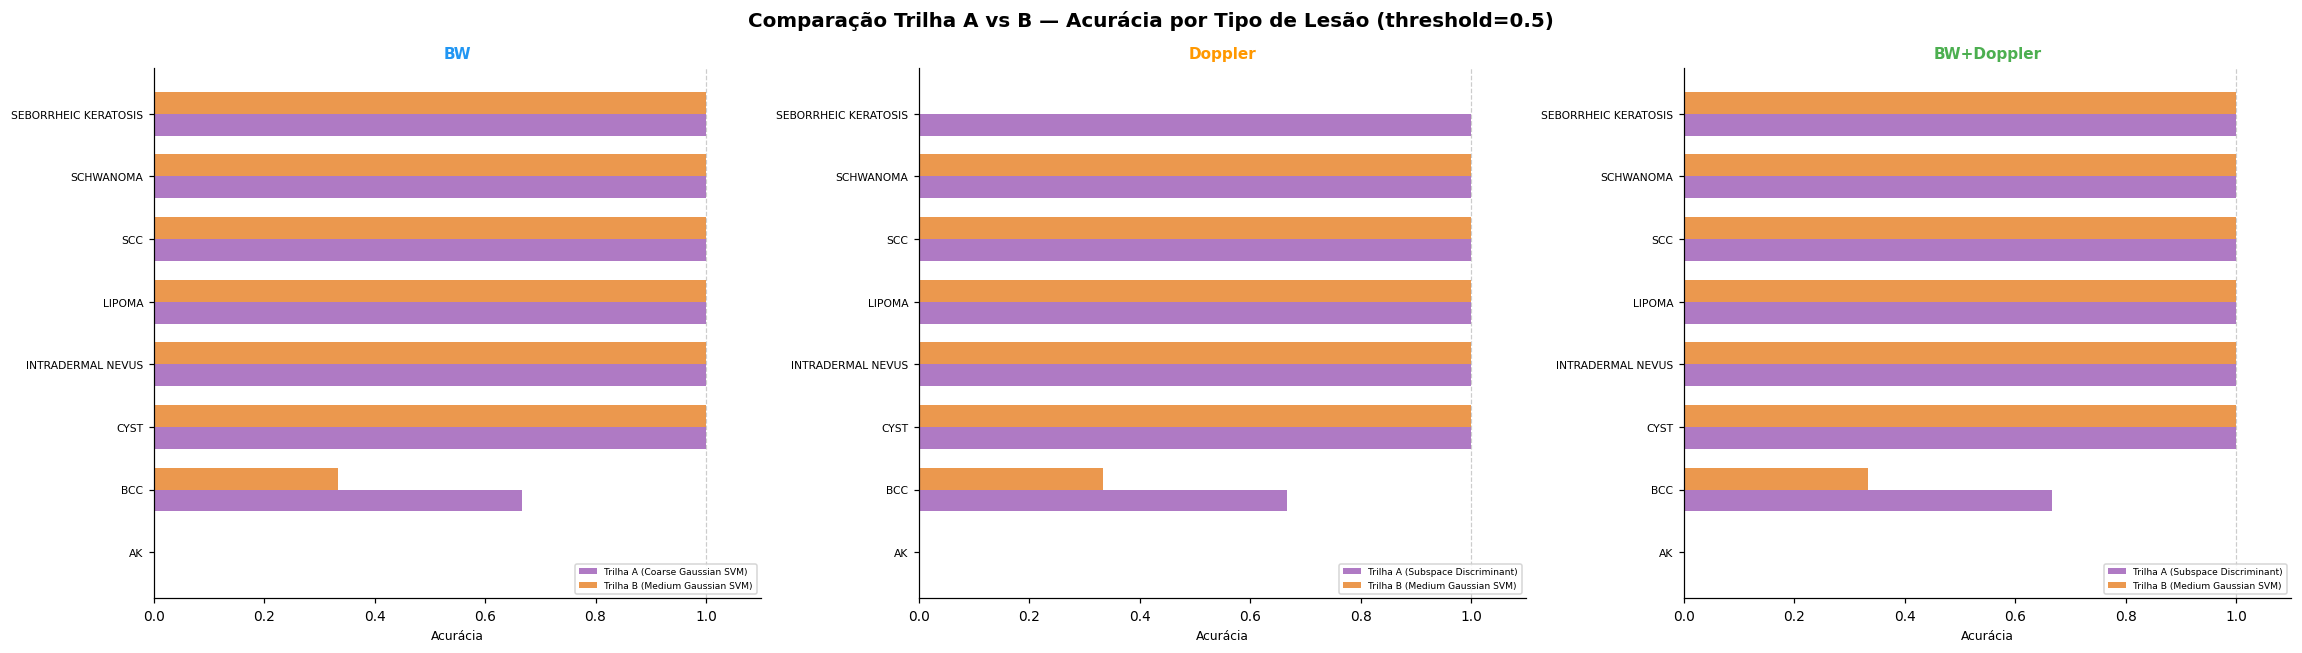

Salvo: c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\analise_por_tipo_lesao\comparison_trilha_a_b_by_lesion.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Comparação Trilha A vs B — Acurácia por Tipo de Lesão (threshold=0.5)',
             fontsize=13, fontweight='bold')

for ax, ds_name in zip(axes, DATASETS.keys()):
    df_a = accuracy_by_lesion(
        splits_a[ds_name]['y_test'],
        test_preds_a[ds_name]['pred_05'],
        splits_a[ds_name]['dx_test'],
    ).set_index('dx')

    df_b = accuracy_by_lesion(
        splits_b[ds_name]['y_test'],
        test_preds_b[ds_name]['pred_05'],
        splits_b[ds_name]['dx_test'],
    ).set_index('dx')

    # Unir pelos tipos comuns
    dx_types = sorted(set(df_a.index) | set(df_b.index))
    acc_a = [df_a.loc[dx, 'accuracy'] if dx in df_a.index else np.nan for dx in dx_types]
    acc_b = [df_b.loc[dx, 'accuracy'] if dx in df_b.index else np.nan for dx in dx_types]

    x = np.arange(len(dx_types))
    width = 0.35
    ax.barh(x - width/2, acc_a, width, label=f'Trilha A ({test_preds_a[ds_name]["model"]})',
            color='#9b59b6', alpha=0.8)
    ax.barh(x + width/2, acc_b, width, label=f'Trilha B ({test_preds_b[ds_name]["model"]})',
            color='#e67e22', alpha=0.8)

    ax.set_yticks(x)
    ax.set_yticklabels(dx_types, fontsize=7)
    ax.set_xlim(0, 1.1)
    ax.axvline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.set_xlabel('Acurácia', fontsize=8)
    ax.set_title(ds_name, fontsize=10, fontweight='bold', color=DS_COLORS[ds_name])
    ax.legend(fontsize=6, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'comparison_trilha_a_b_by_lesion.png')
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'Salvo: {out_png}')

### 9. Tabela resumo — tipos de lesão com erro

In [12]:
df_errors = df_summary[
    (df_summary['threshold'] == 'thr=0.5') & (df_summary['accuracy'] < 1.0)
].copy()

print(f'Tipos de lesão com pelo menos um erro (threshold=0.5):')
display(
    df_errors[['trilha', 'dataset', 'dx', 'label', 'n_images', 'n_correct', 'accuracy']]
    .sort_values(['dx', 'trilha', 'dataset'])
    .reset_index(drop=True)
    .style.format({'accuracy': '{:.2%}'})
    .background_gradient(subset=['accuracy'], cmap='RdYlGn')
)

print(f'\nArquivos gerados em {OUTPUT_DIR}:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) // 1024
    print(f'  {f:<55} {size_kb} KB')

Tipos de lesão com pelo menos um erro (threshold=0.5):


,trilha,dataset,dx,label,n_images,n_correct,accuracy
0,Trilha A,BW,AK,MALIGNANT,1,0,0.00%
1,Trilha A,BW+Doppler,AK,MALIGNANT,1,0,0.00%
2,Trilha A,Doppler,AK,MALIGNANT,1,0,0.00%
3,Trilha B,BW,AK,MALIGNANT,1,0,0.00%
4,Trilha B,BW+Doppler,AK,MALIGNANT,1,0,0.00%
5,Trilha B,Doppler,AK,MALIGNANT,1,0,0.00%
6,Trilha A,BW,BCC,MALIGNANT,3,2,66.67%
7,Trilha A,BW+Doppler,BCC,MALIGNANT,3,2,66.67%
8,Trilha A,Doppler,BCC,MALIGNANT,3,2,66.67%
9,Trilha B,BW,BCC,MALIGNANT,3,1,33.33%



Arquivos gerados em c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\analise_por_tipo_lesao:
  accuracy_by_lesion_type.csv                             6 KB
  comparison_trilha_a_b_by_lesion.png                     48 KB
  trilha_a_accuracy_by_lesion.png                         52 KB
  trilha_b_accuracy_by_lesion.png                         57 KB
